In [28]:
import pickle
import os
from pprint import pprint
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Choose a pickle file (modify this path as needed)
#pickle_file_path = "../results/nanogpt_tanea_results_mixed_bf16_rope_multi_gpu_20250715_080223_steps_80000_bs_4_seq_1024_devices_1_g2_0.00016_g3_0.00016_delta_8.0_flavor_mk3_attn_cudnn.pkl"
pickle_file_path = "../results/nanogpt_tanea_results_mixed_bf16_rope_multi_gpu_20250715_133303_steps_800_bs_4_seq_1024_devices_1_g2_0.00016_g3_0.00016_delta_8.0_flavor_mk3_attn_cudnn.pkl"

Inspect the contents of the file and output the config information

In [29]:

# Load and inspect the pickle file
try:
    with open(pickle_file_path, 'rb') as f:
        data = pickle.load(f)
    
    print("=== PICKLE FILE CONTENTS ===")
    print(f"Type: {type(data)}")
    print(f"File: {pickle_file_path}")
    print("\n=== FULL CONTENTS ===")
    if isinstance(data, dict):
        print("Keys in the loaded pickle file:")
        for key in data.keys():
            print(f"- {key}")
    else:
        print("Loaded object is not a dict. Type:", type(data))
        print("Attributes:")
        for attr in dir(data):
            if not attr.startswith("__"):
                print(f"- {attr}")
    
    print("\n=== CONFIG KEY ===")
    if isinstance(data, dict) and 'config' in data:
        pprint(data['config'])
    elif hasattr(data, 'config'):
        pprint(data.config)
    else:
        print("No 'config' key found in the data")
        if isinstance(data, dict):
            print(f"Available keys: {list(data.keys())}")
        else:
            print(f"Data attributes: {dir(data)}")
            
except FileNotFoundError:
    print(f"File not found: {pickle_file_path}")
    print("Please update the pickle_file_path variable with the correct path")
except Exception as e:
    print(f"Error loading pickle file: {e}")


=== PICKLE FILE CONTENTS ===
Type: <class 'dict'>
File: ../results/nanogpt_tanea_results_mixed_bf16_rope_multi_gpu_20250715_133303_steps_800_bs_4_seq_1024_devices_1_g2_0.00016_g3_0.00016_delta_8.0_flavor_mk3_attn_cudnn.pkl

=== FULL CONTENTS ===
Keys in the loaded pickle file:
- metrics
- tau_statistics
- config
- num_params
- precision
- multi_gpu
- num_devices

=== CONFIG KEY ===
{'attention_implementation': 'cudnn',
 'batch_size': 4,
 'clipsnr': 2.0,
 'decay_fraction': 0.0,
 'disable_checkpoint': False,
 'disable_validation': False,
 'enable_wsd': False,
 'grad_clip': 100.0,
 'init_std': 0.02,
 'model_size': 'GPT2-jumbo',
 'momentum_flavor': 'mk3',
 'num_devices': 1,
 'per_device_batch_size': 4,
 'per_device_val_batch_size': 4,
 'power_weight_decay': 1.0,
 'precision': 'mixed_bfloat16_rope',
 'results_dir': 'results',
 'rope_base': 10000.0,
 'seq_len': 1024,
 'tanea_delta': 8.0,
 'tanea_g2': 0.00016,
 'tanea_g3': 0.00016,
 'tanea_kappa': 0.75,
 'train_steps': 800,
 'val_batch_size':

Plot the loss curve

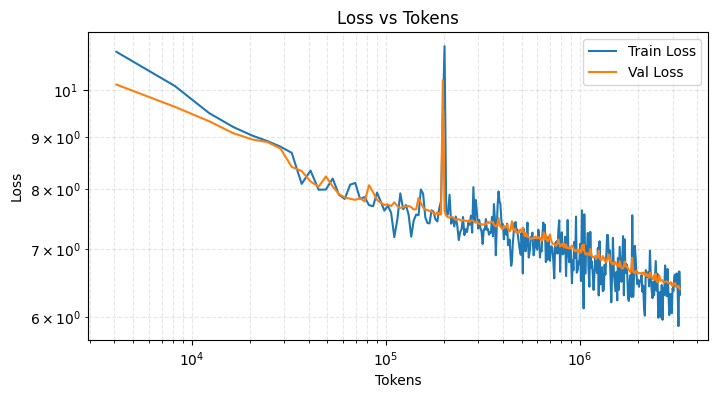

In [30]:
steps = data['metrics']['step']
train_losses = data['metrics']['train_loss']
val_losses = data['metrics']['val_loss']
tokens_per_step = data['config']['batch_size'] * data['config']['seq_len']
tokens = np.array(steps) * tokens_per_step

plt.figure(figsize=(8, 4))
plt.plot(tokens, train_losses)
plt.plot(tokens, val_losses)
plt.legend(['Train Loss', 'Val Loss'])
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.xlabel('Tokens')
plt.ylabel('Loss')
plt.title('Loss vs Tokens')
plt.xscale('log')
plt.yscale('log')
plt.show()


Plot the tau statistics

In [46]:
data['tau_statistics']['tau_statistics'][10]['params']['wte']['embedding']

(array([3.9943233e-01, 3.9337736e-01, 3.9278850e-01, 3.9232427e-01,
        3.9211947e-01, 3.8612288e-01, 3.8602784e-01, 3.8574135e-01,
        3.8535839e-01, 3.8528761e-01, 3.8287666e-01, 3.8155892e-01,
        3.8132834e-01, 3.8102752e-01, 3.8062984e-01, 3.8040712e-01,
        3.7982142e-01, 3.7950885e-01, 3.7832648e-01, 3.7713960e-01,
        3.7695283e-01, 3.7599492e-01, 3.7528810e-01, 3.7465101e-01,
        3.7412000e-01, 3.7342212e-01, 3.7284309e-01, 3.7217012e-01,
        3.7177283e-01, 3.7117013e-01, 3.7058464e-01, 3.7029788e-01,
        3.6869615e-01, 3.6799949e-01, 3.6693576e-01, 3.6616161e-01,
        3.6568126e-01, 3.6499938e-01, 3.6395624e-01, 3.6324012e-01,
        3.6248684e-01, 3.6200535e-01, 3.6117253e-01, 3.6023641e-01,
        3.5958511e-01, 3.5867938e-01, 3.5752028e-01, 3.5679632e-01,
        3.5599017e-01, 3.5523763e-01, 3.5448134e-01, 3.5370073e-01,
        3.5279340e-01, 3.5192326e-01, 3.5092998e-01, 3.4982905e-01,
        3.4897295e-01, 3.4793890e-01, 3.4675533e

In [35]:
max(data['tau_statistics']['timestamps'])

800

Plot head statistics

/opt/e-py/lib/python3.12/site-packages/numpy/_core/numeric.py:442: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


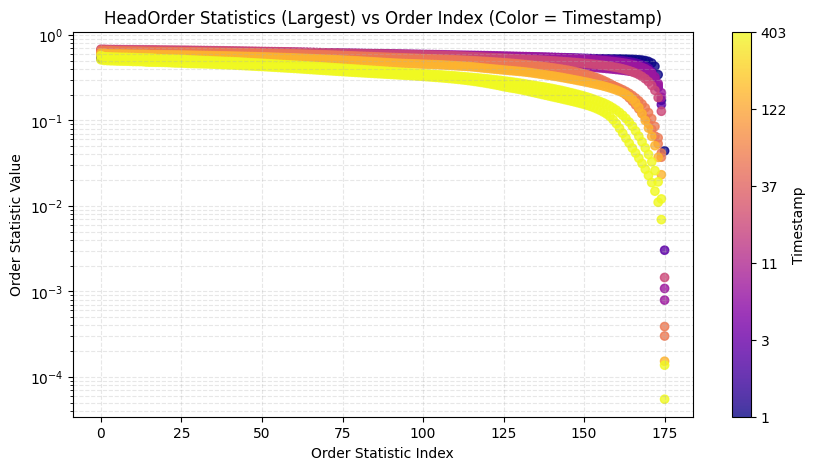

In [ ]:
timestamps = data['tau_statistics']['timestamps']
all_order_statistics = data['tau_statistics']['tau_statistics']
#data['tau_statistics']['tau_statistics'][1]['params']['head']['kernel']

# 2D scatter plot: order statistics vs order index, color by timestamp
# Prepare data for 2D plot
order_indices = []
order_values = []
order_timestamps = []

for t_idx, (ts, arr) in enumerate(zip(timestamps, all_order_statistics)):
    arr = arr['params']['head']['kernel'][0]
    arr = np.asarray(arr)
    for order_idx, val in enumerate(arr):
        order_indices.append(order_idx)
        order_values.append(val)
        order_timestamps.append(ts)

order_indices = np.array(order_indices)
order_values = np.array(order_values)
order_timestamps = np.array(order_timestamps)

plt.figure(figsize=(10, 5))

# Use log of order_timestamps for color, but keep original timestamps for colorbar ticks
# Filter out zero and negative values to avoid log warnings
valid_mask = order_timestamps > 0
log_order_timestamps = np.full_like(order_timestamps, np.nan)
log_order_timestamps[valid_mask] = np.log(order_timestamps[valid_mask])
sc2 = plt.scatter(order_indices, order_values, c=log_order_timestamps, cmap='plasma', alpha=0.8)

plt.xlabel('Order Statistic Index')
plt.ylabel('Order Statistic Value')
plt.title('Head Order Statistics (Largest) vs Order Index (Color = Timestamp)')

# Create colorbar with ticks labeled as order_timestamps
cbar = plt.colorbar(sc2)
cbar.set_label('Timestamp')

# Set colorbar ticks to correspond to a few representative timestamps
num_ticks = 6
if len(order_timestamps) > 0 and np.any(valid_mask):
    # Choose ticks evenly spaced in log space, only for valid values
    log_min = np.nanmin(log_order_timestamps[valid_mask])
    log_max = np.nanmax(log_order_timestamps[valid_mask])
    if not np.isnan(log_min) and not np.isnan(log_max) and log_min != log_max:
        log_tick_locs = np.linspace(log_min, log_max, num_ticks)
        # Convert back to timestamp for labeling
        tick_labels = [f"{np.exp(ltick):.0f}" for ltick in log_tick_locs]
        cbar.set_ticks(log_tick_locs)
        cbar.set_ticklabels(tick_labels)

plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.show()

/opt/e-py/lib/python3.12/site-packages/numpy/_core/numeric.py:442: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


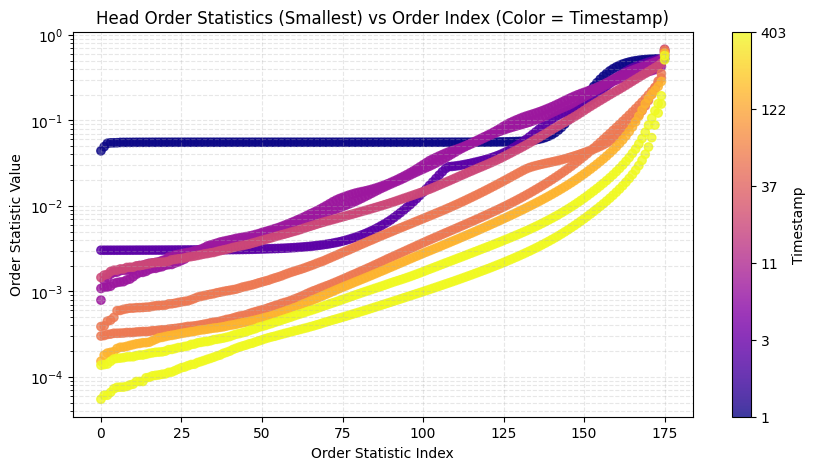

In [39]:
timestamps = data['tau_statistics']['timestamps']
all_order_statistics = data['tau_statistics']['tau_statistics']
#data['tau_statistics']['tau_statistics'][1]['params']['head']['kernel']

# 2D scatter plot: order statistics vs order index, color by timestamp
# Prepare data for 2D plot
order_indices = []
order_values = []
order_timestamps = []

for t_idx, (ts, arr) in enumerate(zip(timestamps, all_order_statistics)):
    arr = np.asarray(arr['params']['head']['kernel'][1])
    for order_idx, val in enumerate(arr):
        order_indices.append(order_idx)
        order_values.append(val)
        order_timestamps.append(ts)

order_indices = np.array(order_indices)
order_values = np.array(order_values)
order_timestamps = np.array(order_timestamps)

plt.figure(figsize=(10, 5))

# Use log of order_timestamps for color, but keep original timestamps for colorbar ticks
# Filter out zero and negative values to avoid log warnings
valid_mask = order_timestamps > 0
log_order_timestamps = np.full_like(order_timestamps, np.nan)
log_order_timestamps[valid_mask] = np.log(order_timestamps[valid_mask])
sc2 = plt.scatter(order_indices, order_values, c=log_order_timestamps, cmap='plasma', alpha=0.8)

plt.xlabel('Order Statistic Index')
plt.ylabel('Order Statistic Value')
plt.title('Head Order Statistics (Smallest) vs Order Index (Color = Timestamp)')

# Create colorbar with ticks labeled as order_timestamps
cbar = plt.colorbar(sc2)
cbar.set_label('Timestamp')

# Set colorbar ticks to correspond to a few representative timestamps
num_ticks = 6
if len(order_timestamps) > 0 and np.any(valid_mask):
    # Choose ticks evenly spaced in log space, only for valid values
    log_min = np.nanmin(log_order_timestamps[valid_mask])
    log_max = np.nanmax(log_order_timestamps[valid_mask])
    if not np.isnan(log_min) and not np.isnan(log_max) and log_min != log_max:
        log_tick_locs = np.linspace(log_min, log_max, num_ticks)
        # Convert back to timestamp for labeling
        tick_labels = [f"{np.exp(ltick):.0f}" for ltick in log_tick_locs]
        cbar.set_ticks(log_tick_locs)
        cbar.set_ticklabels(tick_labels)

plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.show()

Embed layer